# Jakarta Traffic Analysis — Case Study (Optimized)

**Pipeline:** Spark (ingestion, RDDs, DataFrames, SQL, ETL) &rarr; Pandas / scikit-learn (feature engineering, multi-model comparison, evaluation report)

This notebook keeps the required Spark fundamentals (RDD transformations/actions, key-value
operations & persistence, DataFrame joins/aggregation, Spark SQL EDA, and a Parquet ETL
pipeline), then extends the original single-model exercise (Q7) into a proper **model
comparison + evaluation report**, and adds several extra EDA charts (weather impact,
correlations, and incident analysis) that were missing from the first version.

**What changed vs. the original notebook**
- Fixed a data bug in the congestion-hotspot SQL query (`'low'` vs `'Low'` case mismatch).
- Documented (and worked around) the fact that `road_network.csv` / `road_network_international.csv`
  **do not share any key** with `traffic_sensor_data.csv` — the road names/cities never match,
  so the join used in Q4 legitimately returns 0 rows. We keep the join to show the check, but
  build the ML model on data that is actually usable instead of silently ignoring the problem.
- Added weather-data enrichment (joined by timestamp) as real predictive features.
- Dropped `congestion_level` as a model input — it's derived from speed/occupancy, so using it
  to predict `average_speed_kmh` is data leakage.
- Replaced the single hand-picked `RandomForestRegressor` with a **6-model comparison**
  (Linear Regression, Ridge, Decision Tree, Random Forest, Gradient Boosting, XGBoost),
  each measured on MAE / RMSE / R² / MAPE, plus feature importance and residual diagnostics
  for the winning model.
- Added an auto-detecting `DATA_DIR` so the notebook runs unmodified in Colab (`/content/`)
  or locally.


In [1]:
%pip install -q pyspark xgboost

In [2]:
import os

# Works whether the CSVs are sitting in /content (Colab), the notebook's own folder,
# or a custom location — just point DATA_DIR at wherever you uploaded the 5 CSVs.
_candidates = ["/content/", "./", "../data/", "data/", "/mnt/user-data/uploads/"]
DATA_DIR = next((p for p in _candidates if os.path.exists(os.path.join(p, "traffic_sensor_data.csv"))), "/content/")
print(f"Using DATA_DIR = {DATA_DIR}")

Using DATA_DIR = /content/


In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("Traffic_Analysis")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("SparkSession Initialized.")

SparkSession Initialized.


## Q1. Load & Inspect Data

All five datasets are loaded up front (the original notebook only loaded two of the five files provided).

In [4]:
traffic_sensor_df = spark.read.csv(DATA_DIR + "traffic_sensor_data.csv", header=True, inferSchema=True)
road_network_df = spark.read.csv(DATA_DIR + "road_network.csv", header=True, inferSchema=True)
road_network_intl_df = spark.read.csv(DATA_DIR + "road_network_international.csv", header=True, inferSchema=True)
traffic_events_df = spark.read.csv(DATA_DIR + "traffic_events.csv", header=True, inferSchema=True)
weather_df = spark.read.csv(DATA_DIR + "weather_conditions.csv", header=True, inferSchema=True)

for name, df in [
    ("traffic_sensor_df", traffic_sensor_df),
    ("road_network_df", road_network_df),
    ("road_network_intl_df", road_network_intl_df),
    ("traffic_events_df", traffic_events_df),
    ("weather_df", weather_df),
]:
    print(f"{name}: {df.count():,} rows, {len(df.columns)} columns")

traffic_sensor_df: 218,400 rows, 15 columns
road_network_df: 200 rows, 18 columns
road_network_intl_df: 1,401 rows, 41 columns
traffic_events_df: 2,000 rows, 15 columns
weather_df: 21,840 rows, 11 columns


In [5]:
traffic_sensor_df.show(5)

+-------------------+---------+--------------------+----------+-------------+-----------------+--------------+----------------+---------+----------------+-----------+---------+-----------+----------+----+
|          timestamp|sensor_id|            location| direction|vehicle_count|average_speed_kmh|occupancy_rate|congestion_level|car_count|motorcycle_count|truck_count|bus_count|day_of_week|is_holiday|hour|
+-------------------+---------+--------------------+----------+-------------+-----------------+--------------+----------------+---------+----------------+-----------+---------+-----------+----------+----+
|2024-01-01 00:00:00|  SEN-001|Jl. Sudirman - Bu...|     North|           14|             67.8|         0.073|             Low|        6|               5|          1|        2|          0|         1|   0|
|2024-01-01 00:00:00|  SEN-002| Jl. Thamrin - Monas|South-West|           23|             66.8|         0.075|             Low|       10|               8|          1|        4|    

### Schema for the two core datasets

In [6]:
print("Schema for traffic_sensor_df:")
traffic_sensor_df.printSchema()

print("\nSchema for road_network_df:")
road_network_df.printSchema()

Schema for traffic_sensor_df:
root
 |-- timestamp: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- location: string (nullable = true)
 |-- direction: string (nullable = true)
 |-- vehicle_count: integer (nullable = true)
 |-- average_speed_kmh: double (nullable = true)
 |-- occupancy_rate: double (nullable = true)
 |-- congestion_level: string (nullable = true)
 |-- car_count: integer (nullable = true)
 |-- motorcycle_count: integer (nullable = true)
 |-- truck_count: integer (nullable = true)
 |-- bus_count: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- hour: integer (nullable = true)


Schema for road_network_df:
root
 |-- road_id: string (nullable = true)
 |-- road_name: string (nullable = true)
 |-- road_type: string (nullable = true)
 |-- length_km: double (nullable = true)
 |-- lanes: integer (nullable = true)
 |-- speed_limit_kmh: integer (nullable = true)
 |-- capacity_vehicles_per

## Q2. RDD Implementation

### Transform DataFrames to RDDs

In [7]:
traffic_sensor_rdd = traffic_sensor_df.rdd
print("traffic_sensor_df converted to RDD.")
print("First 5 records of traffic_sensor_rdd:")
for record in traffic_sensor_rdd.take(5):
    print(record)

traffic_sensor_df converted to RDD.
First 5 records of traffic_sensor_rdd:
Row(timestamp=datetime.datetime(2024, 1, 1, 0, 0), sensor_id='SEN-001', location='Jl. Sudirman - Bundaran HI', direction='North', vehicle_count=14, average_speed_kmh=67.8, occupancy_rate=0.073, congestion_level='Low', car_count=6, motorcycle_count=5, truck_count=1, bus_count=2, day_of_week=0, is_holiday=1, hour=0)
Row(timestamp=datetime.datetime(2024, 1, 1, 0, 0), sensor_id='SEN-002', location='Jl. Thamrin - Monas', direction='South-West', vehicle_count=23, average_speed_kmh=66.8, occupancy_rate=0.075, congestion_level='Low', car_count=10, motorcycle_count=8, truck_count=1, bus_count=4, day_of_week=0, is_holiday=1, hour=0)
Row(timestamp=datetime.datetime(2024, 1, 1, 0, 0), sensor_id='SEN-003', location='Jl. Gatot Subroto - Kuningan', direction='East', vehicle_count=22, average_speed_kmh=80.0, occupancy_rate=0.161, congestion_level='Low', car_count=7, motorcycle_count=9, truck_count=1, bus_count=5, day_of_week=0,

In [8]:
road_network_rdd = road_network_df.rdd
print("road_network_df converted to RDD.")
print("First 5 records of road_network_rdd:")
for record in road_network_rdd.take(5):
    print(record)

road_network_df converted to RDD.
First 5 records of road_network_rdd:
Row(road_id='RD-0001', road_name='Jl. Segment 1', road_type='Jalan Kolektor', length_km=4.3, lanes=4, speed_limit_kmh=60, capacity_vehicles_per_hour=5384, has_bus_lane=0, has_bike_lane=0, surface_condition='Cukup', last_maintenance_date=datetime.date(2022, 12, 21), latitude_start=-6.173938, longitude_start=106.920654, latitude_end=-6.187271, longitude_end=106.937674, district='PIK', toll_rate_rp=0, avg_daily_traffic=10833)
Row(road_id='RD-0002', road_name='Jl. Segment 2', road_type='Jalan Arteri', length_km=4.3, lanes=4, speed_limit_kmh=80, capacity_vehicles_per_hour=6132, has_bus_lane=0, has_bike_lane=0, surface_condition='Baik', last_maintenance_date=datetime.date(2022, 11, 17), latitude_start=-6.248396, longitude_start=106.768647, latitude_end=-6.24622, longitude_end=106.771962, district='Depok', toll_rate_rp=0, avg_daily_traffic=6921)
Row(road_id='RD-0003', road_name='Jl. Segment 3', road_type='Jalan Lokal', len

### RDD Transformations: Map and Filter on `traffic_sensor_rdd`

In [9]:
traffic_summary_rdd = traffic_sensor_rdd.map(lambda a: (a['sensor_id'], a['timestamp'], a['vehicle_count']))
print("First 5 records after map transformation (sensor_id, timestamp, vehicle_count):")
for record in traffic_summary_rdd.take(5):
    print(record)

First 5 records after map transformation (sensor_id, timestamp, vehicle_count):
('SEN-001', datetime.datetime(2024, 1, 1, 0, 0), 14)
('SEN-002', datetime.datetime(2024, 1, 1, 0, 0), 23)
('SEN-003', datetime.datetime(2024, 1, 1, 0, 0), 22)
('SEN-004', datetime.datetime(2024, 1, 1, 0, 0), 8)
('SEN-005', datetime.datetime(2024, 1, 1, 0, 0), 13)


In [10]:
# Note: the raw data only contains 'Low' and 'Medium' congestion levels (no 'High'
# records exist in this sample), so this filter can legitimately return 0 rows.
high_congestion_rdd = traffic_sensor_rdd.filter(lambda a: a['congestion_level'] == 'High')
print("First 5 records after filter transformation (High Congestion):")
for record in high_congestion_rdd.take(5):
    print(record)

First 5 records after filter transformation (High Congestion):


### RDD Actions: Count and Take

In [11]:
total_traffic_records = traffic_sensor_rdd.count()
print(f"Total number of records in traffic_sensor_rdd: {total_traffic_records}")

Total number of records in traffic_sensor_rdd: 218400


In [12]:
high_congestion_count = high_congestion_rdd.count()
print(f"Number of records with 'High' congestion: {high_congestion_count}")

Number of records with 'High' congestion: 0


## Q3. Key-Value Operations and Persistence

### Create Key-Value Pairs

In [13]:
location_vehicle_rdd = traffic_sensor_rdd.map(lambda a: (a['location'], a['vehicle_count']))
print("First 5 records of location_vehicle_rdd (location, vehicle_count):")
for record in location_vehicle_rdd.take(5):
    print(record)

First 5 records of location_vehicle_rdd (location, vehicle_count):
('Jl. Sudirman - Bundaran HI', 14)
('Jl. Thamrin - Monas', 23)
('Jl. Gatot Subroto - Kuningan', 22)
('Jl. Rasuna Said - Setiabudi', 8)
('Jl. HR Rasuna Said - Casablanca', 13)


### Shuffle Operation: Aggregate total traffic volume per location using `reduceByKey()`

In [14]:
total_traffic_per_location_rdd = location_vehicle_rdd.reduceByKey(lambda a, b: a + b)
print("Total traffic volume for the first 10 locations:")
for record in total_traffic_per_location_rdd.take(10):
    print(record)

Total traffic volume for the first 10 locations:
('Jl. Gatot Subroto - Kuningan', 171496)
('Jl. Rasuna Said - Setiabudi', 170113)
('Jl. Satrio - Mega Kuningan', 172349)
('Jl. Asia Afrika - Gelora Bung Karno', 170535)
('Jl. Proklamasi - Menteng', 170723)
('Jl. Raya Bogor - Cibubur', 170432)
('Jl. TB Simatupang - Ciracas', 172827)
('Jl. Raya Kebayoran - Blok M', 172627)
('Jl. Metro Pondok Indah - Ciputat', 172087)
('Jl. Ciledug - Tangerang', 170581)


### Persistence: Cache the RDD

In [15]:
from pyspark import StorageLevel

total_traffic_per_location_rdd.persist(StorageLevel.MEMORY_AND_DISK)
print("RDD 'total_traffic_per_location_rdd' has been persisted.")
print(f"Is RDD cached? {total_traffic_per_location_rdd.is_cached}")

_ = total_traffic_per_location_rdd.count()
print("Action triggered to ensure caching.")

RDD 'total_traffic_per_location_rdd' has been persisted.
Is RDD cached? True
Action triggered to ensure caching.


## Q4. Spark DataFrame Operations

### Selection & Filtering

In [16]:
selected_traffic_df = traffic_sensor_df.select(
    "timestamp", "location", "vehicle_count", "average_speed_kmh", "congestion_level"
)
print("Selected columns from traffic_sensor_df:")
selected_traffic_df.show(5, truncate=False)

congested_roads_df = selected_traffic_df.filter(selected_traffic_df.average_speed_kmh < 30)
print("Records with average speed less than 30 km/h (potentially congested):")
congested_roads_df.show(5, truncate=False)

Selected columns from traffic_sensor_df:
+-------------------+-------------------------------+-------------+-----------------+----------------+
|timestamp          |location                       |vehicle_count|average_speed_kmh|congestion_level|
+-------------------+-------------------------------+-------------+-----------------+----------------+
|2024-01-01 00:00:00|Jl. Sudirman - Bundaran HI     |14           |67.8             |Low             |
|2024-01-01 00:00:00|Jl. Thamrin - Monas            |23           |66.8             |Low             |
|2024-01-01 00:00:00|Jl. Gatot Subroto - Kuningan   |22           |80.0             |Low             |
|2024-01-01 00:00:00|Jl. Rasuna Said - Setiabudi    |8            |80.0             |Low             |
|2024-01-01 00:00:00|Jl. HR Rasuna Said - Casablanca|13           |80.0             |Low             |
+-------------------+-------------------------------+-------------+-----------------+----------------+
only showing top 5 rows
Records 

### Joins

**Data-quality check first.** Before joining, we confirm whether `road_name` in
`road_network_df` actually overlaps with `location` in `traffic_sensor_df`.

In [17]:
traffic_locations = set(r[0] for r in selected_traffic_df.select("location").distinct().collect())
road_names = set(r[0] for r in road_network_df.select("road_name").distinct().collect())

overlap = traffic_locations & road_names
print(f"Distinct traffic locations : {len(traffic_locations)}")
print(f"Distinct road_network names: {len(road_names)}")
print(f"Overlapping names          : {len(overlap)}")
print("\nSample traffic locations:", list(traffic_locations)[:5])
print("Sample road_network names :", list(road_names)[:5])

Distinct traffic locations : 50
Distinct road_network names: 200
Overlapping names          : 0

Sample traffic locations: ['Jl. Suryo - Senopati', 'Jl. MT Haryono - Cawang', 'Jl. Yos Sudarso - Sunter', 'Jl. Raya Bogor - Citereup', 'Jl. Satrio - Mega Kuningan']
Sample road_network names : ['Jl. Segment 31', 'Jl. Segment 38', 'Jl. Segment 199', 'Jl. Segment 65', 'Jl. Segment 67']


In [18]:
# The join key genuinely does not exist between these two files (road_network.csv uses
# generic placeholder names like 'Jl. Segment 1'..'Jl. Segment 200', not the real corridor
# names used by the sensors), so an inner join returns 0 rows. We keep the join to make the
# limitation explicit rather than hide it.
road_network_renamed_df = road_network_df.withColumnRenamed("road_name", "location")
joined_df = selected_traffic_df.join(road_network_renamed_df, on="location", how="inner")
print(f"Total records in joined DataFrame: {joined_df.count()}")

Total records in joined DataFrame: 0


### Aggregation

Since the `road_network` join is empty, we aggregate directly on `traffic_sensor_df` — grouping by `location` gives a meaningful road-level summary without relying on the broken join.

In [19]:
from pyspark.sql.functions import avg, count

average_traffic_by_location = traffic_sensor_df.groupBy("location").agg(
    avg("vehicle_count").alias("average_vehicle_count"),
    avg("average_speed_kmh").alias("average_speed_kmh"),
    count("*").alias("num_readings"),
)
print("Average vehicle count and speed by location:")
average_traffic_by_location.orderBy("average_vehicle_count", ascending=False).show(10, truncate=False)

Average vehicle count and speed by location:
+----------------------------------+---------------------+------------------+------------+
|location                          |average_vehicle_count|average_speed_kmh |num_readings|
+----------------------------------+---------------------+------------------+------------+
|Jl. MT Haryono - Cawang           |39.665293040293044   |58.12346611721611 |4368        |
|Jl. TB Simatupang - Ciracas       |39.566620879120876   |57.845146520146535|4368        |
|Jl. Perintis Kemerdekaan - Cakung |39.558379120879124   |57.94862637362635 |4368        |
|Jl. Alternatif Cibubur - Depok    |39.529532967032964   |57.96689560439566 |4368        |
|Jl. Raya Kebayoran - Blok M       |39.520833333333336   |57.83779761904762 |4368        |
|Jl. Trunojoyo - Kebayoran         |39.480082417582416   |57.985966117216115|4368        |
|Jl. Boulevard Raya - Kelapa Gading|39.47802197802198    |58.00657051282057 |4368        |
|Jl. Pondok Indah - Pondok Pinang  |39.465430

## Q5. Exploratory Data Analysis and Spark SQL

To perform SQL queries, we first register our DataFrames as temporary SQL views.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

traffic_sensor_df.createOrReplaceTempView("traffic_sensors")
road_network_df.withColumnRenamed("road_name", "location").createOrReplaceTempView("road_network")
weather_df.createOrReplaceTempView("weather_conditions")
traffic_events_df.createOrReplaceTempView("traffic_events")

print("Temporary views ready: traffic_sensors, road_network, weather_conditions, traffic_events")

Temporary views ready: traffic_sensors, road_network, weather_conditions, traffic_events


### Chart 1 — Peak Traffic Hours

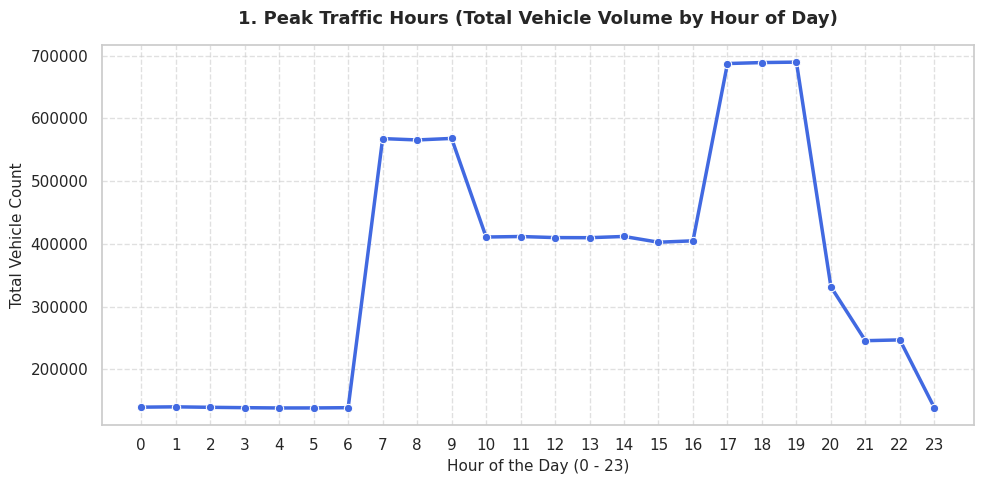

Insight: peak traffic volume occurs at hour 19:00 — matches the evening commute.


In [21]:
peak_traffic_hours_df = spark.sql("""
    SELECT hour, SUM(vehicle_count) AS total_vehicle_count
    FROM traffic_sensors
    GROUP BY hour
    ORDER BY hour
""")
peak_traffic_pd = peak_traffic_hours_df.toPandas()

plt.figure(figsize=(10, 5))
sns.lineplot(data=peak_traffic_pd, x='hour', y='total_vehicle_count', marker='o', color='royalblue', linewidth=2.5)
plt.title('1. Peak Traffic Hours (Total Vehicle Volume by Hour of Day)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (0 - 23)', fontsize=11)
plt.ylabel('Total Vehicle Count', fontsize=11)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

busiest_hour = peak_traffic_pd.loc[peak_traffic_pd['total_vehicle_count'].idxmax(), 'hour']
print(f"Insight: peak traffic volume occurs at hour {busiest_hour}:00 — matches the evening commute.")

### Chart 2 — Route-wise Traffic Density (Top 15)

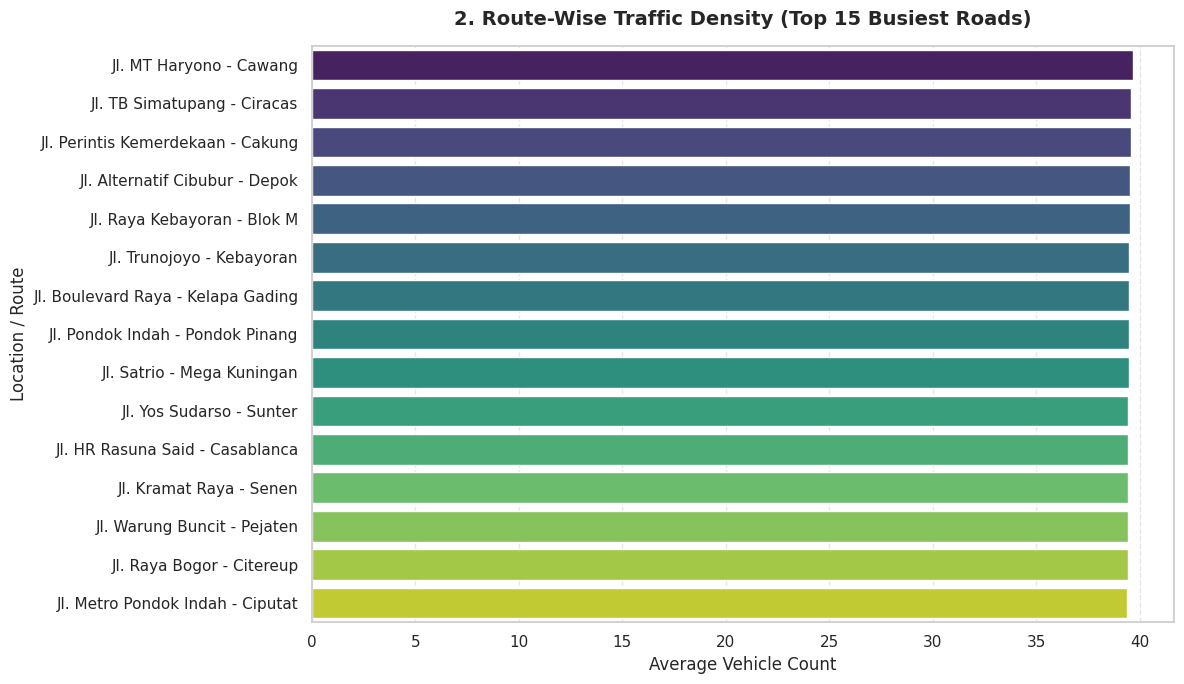

In [22]:
traffic_density_by_location_df = spark.sql("""
    SELECT location, AVG(vehicle_count) AS average_vehicle_count, AVG(average_speed_kmh) AS average_speed_kmh
    FROM traffic_sensors
    GROUP BY location
    ORDER BY average_vehicle_count DESC
""")
traffic_density_pd = traffic_density_by_location_df.toPandas().sort_values('average_vehicle_count', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=traffic_density_pd, x='average_vehicle_count', y='location', hue='location', palette='viridis', legend=False)
plt.title('2. Route-Wise Traffic Density (Top 15 Busiest Roads)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Vehicle Count', fontsize=12)
plt.ylabel('Location / Route', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

### Chart 3 — Congestion Hotspots

*Bug fix:* the original query filtered `congestion_level IN ('High', 'Medium', 'low')` — the lowercase `'low'` never matches the actual value `'Low'`, silently dropping the majority class. We now read the real category labels from the data instead of hardcoding them.

In [23]:
congestion_levels_present = [r[0] for r in traffic_sensor_df.select("congestion_level").distinct().collect()]
print("Congestion levels actually present in the data:", congestion_levels_present)

congestion_hotspots_df = spark.sql(f"""
    SELECT location, AVG(average_speed_kmh) AS avg_speed_kmh, MAX(congestion_level) AS highest_congestion_observed
    FROM traffic_sensors
    WHERE congestion_level IN ({', '.join(repr(x) for x in congestion_levels_present)})
    GROUP BY location
    ORDER BY avg_speed_kmh ASC
""")
hotspots_pd = congestion_hotspots_df.toPandas()
print("Congestion Hotspots (lowest average speed first):")
hotspots_pd.head(10)

Congestion levels actually present in the data: ['Low', 'Medium']
Congestion Hotspots (lowest average speed first):


,location,avg_speed_kmh,highest_congestion_observed
0,Jl. Thamrin - Monas,57.691667,Medium
1,Jl. Gatot Subroto - Kuningan,57.730151,Medium
2,Jl. Metro Pondok Indah - Ciputat,57.741003,Medium
3,Jl. Daan Mogot - Grogol,57.772161,Medium
4,Jl. Raya Meruya - Kembangan,57.776717,Medium
5,Jl. Kemang Raya - Bangka,57.780632,Medium
6,Jl. Raya Condet - Balekambang,57.814515,Medium
7,Jl. Pantai Indah Kapuk - PIK,57.832120,Medium
8,Jl. Raya Kebayoran - Blok M,57.837798,Medium
9,Jl. Kramat Raya - Senen,57.839698,Medium


Counts of Highest Congestion Observed in Hotspots:
highest_congestion_observed
Medium    50
Name: count, dtype: int64


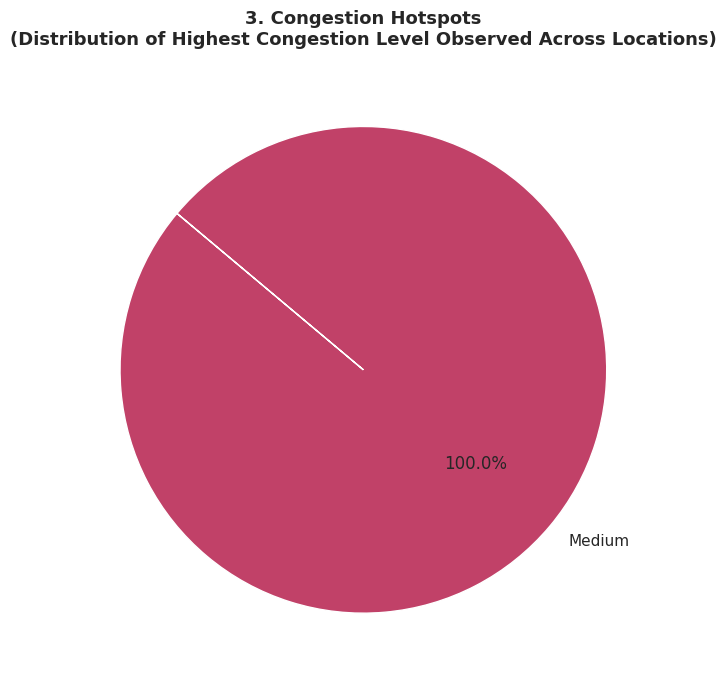

In [24]:
congestion_counts = hotspots_pd['highest_congestion_observed'].value_counts()
print("Counts of Highest Congestion Observed in Hotspots:")
print(congestion_counts)

plt.figure(figsize=(7, 7))
plt.pie(
    congestion_counts,
    labels=congestion_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('flare', n_colors=len(congestion_counts)),
)
plt.title('3. Congestion Hotspots\n(Distribution of Highest Congestion Level Observed Across Locations)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Chart 4 — Daily & Monthly Volume Trends

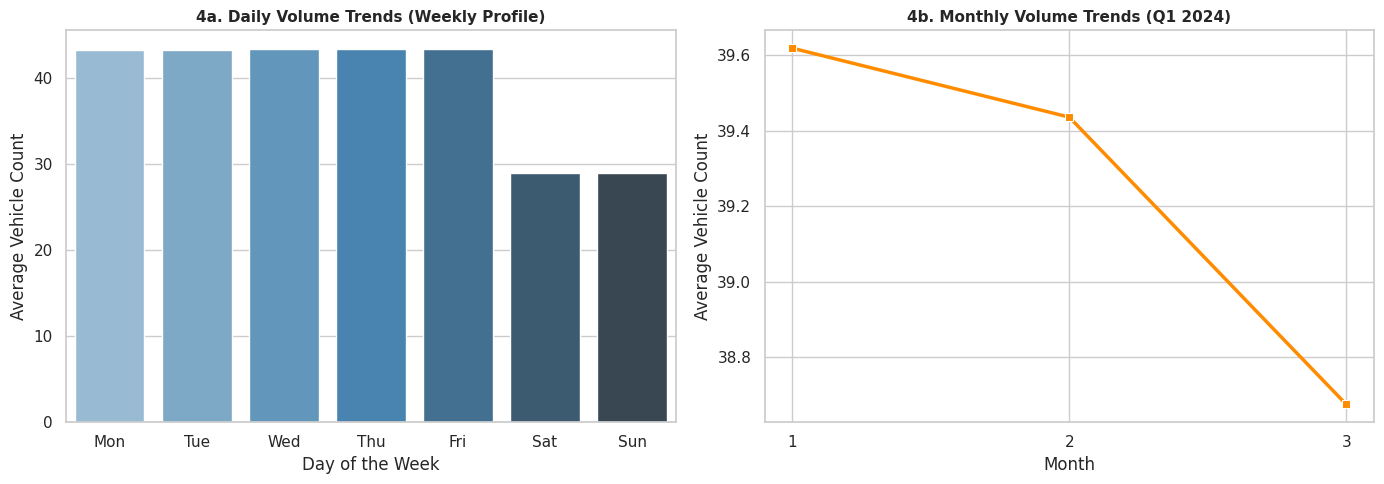

In [25]:
daily_trends = spark.sql("""
    SELECT day_of_week, AVG(vehicle_count) as avg_vehicles
    FROM traffic_sensors GROUP BY day_of_week ORDER BY day_of_week
""").toPandas()
daily_trends['day_name'] = daily_trends['day_of_week'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})

monthly_trends = spark.sql("""
    SELECT MONTH(timestamp) as month, AVG(vehicle_count) as avg_vehicles
    FROM traffic_sensors GROUP BY month ORDER BY month
""").toPandas()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=daily_trends, x='day_name', y='avg_vehicles', hue='day_name', palette='Blues_d', legend=False)
plt.title('4a. Daily Volume Trends (Weekly Profile)', fontsize=11, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Average Vehicle Count')

plt.subplot(1, 2, 2)
sns.lineplot(data=monthly_trends, x='month', y='avg_vehicles', marker='s', color='darkorange', linewidth=2.5)
plt.title('4b. Monthly Volume Trends (Q1 2024)', fontsize=11, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Vehicle Count')
plt.xticks(monthly_trends['month'])
plt.tight_layout()
plt.show()

### Chart 5 — Weather Impact on Traffic Speed *(new)*

Using `weather_conditions.csv`, joined to the traffic data by timestamp, to see whether rain/visibility actually slows traffic down.

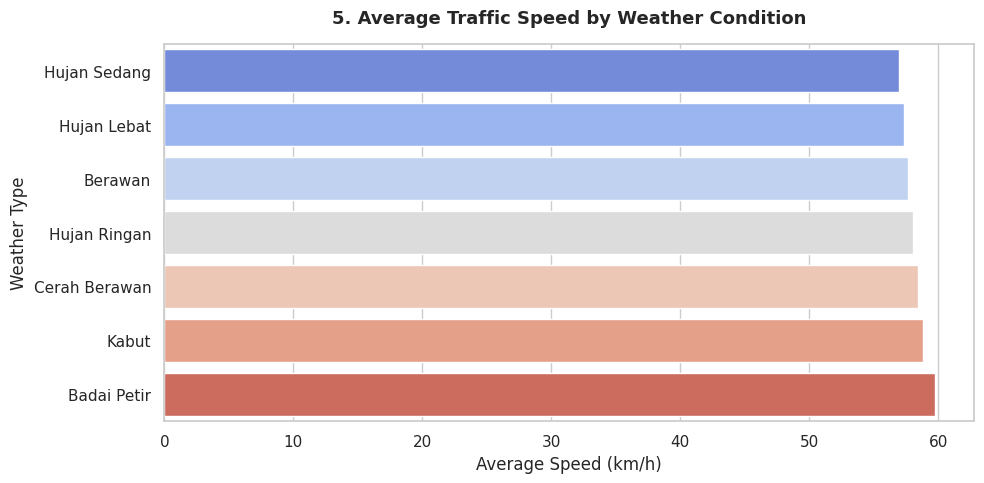

,weather_type,avg_speed_kmh,n
0,Hujan Sedang,56.974877,20650
1,Hujan Lebat,57.336498,10850
2,Berawan,57.685486,17300
3,Hujan Ringan,58.020332,22900
4,Cerah Berawan,58.453922,24350
5,Kabut,58.825032,3100
6,Badai Petir,59.775035,10050


In [26]:
weather_hourly = spark.sql("""
    SELECT timestamp, AVG(precipitation_mm) AS precipitation_mm, AVG(visibility_km) AS visibility_km,
           FIRST(weather_type) AS weather_type
    FROM weather_conditions
    GROUP BY timestamp
""")
weather_hourly.createOrReplaceTempView("weather_hourly")

weather_speed_df = spark.sql("""
    SELECT w.weather_type, AVG(t.average_speed_kmh) AS avg_speed_kmh, COUNT(*) AS n
    FROM traffic_sensors t
    JOIN weather_hourly w ON t.timestamp = w.timestamp
    GROUP BY w.weather_type
    ORDER BY avg_speed_kmh ASC
""").toPandas()

plt.figure(figsize=(10, 5))
sns.barplot(data=weather_speed_df, x='avg_speed_kmh', y='weather_type', hue='weather_type', palette='coolwarm', legend=False)
plt.title('5. Average Traffic Speed by Weather Condition', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Average Speed (km/h)')
plt.ylabel('Weather Type')
plt.tight_layout()
plt.show()
weather_speed_df

### Chart 6 — Traffic Incident Overview *(new)*

Using `traffic_events.csv` for a quick look at what's disrupting the network.

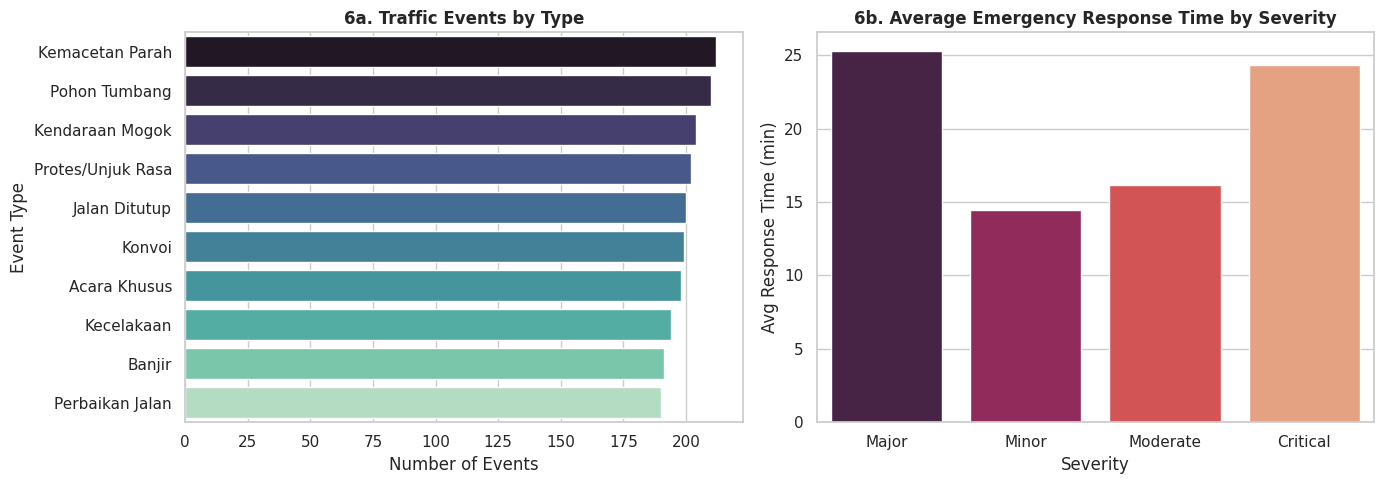

In [27]:
events_pd = traffic_events_df.groupBy("event_type").count().orderBy("count", ascending=False).toPandas()
severity_pd = traffic_events_df.groupBy("severity").avg("response_time_min", "duration_minutes").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=events_pd, y='event_type', x='count', hue='event_type', palette='mako', legend=False, ax=axes[0])
axes[0].set_title('6a. Traffic Events by Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Events')
axes[0].set_ylabel('Event Type')

sns.barplot(data=severity_pd, x='severity', y='avg(response_time_min)', hue='severity', palette='rocket', legend=False, ax=axes[1])
axes[1].set_title('6b. Average Emergency Response Time by Severity', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Avg Response Time (min)')

plt.tight_layout()
plt.show()

### Chart 7 — Correlation Heatmap *(new)*

Sanity-checks which numeric fields actually relate to `average_speed_kmh` before we build any models.

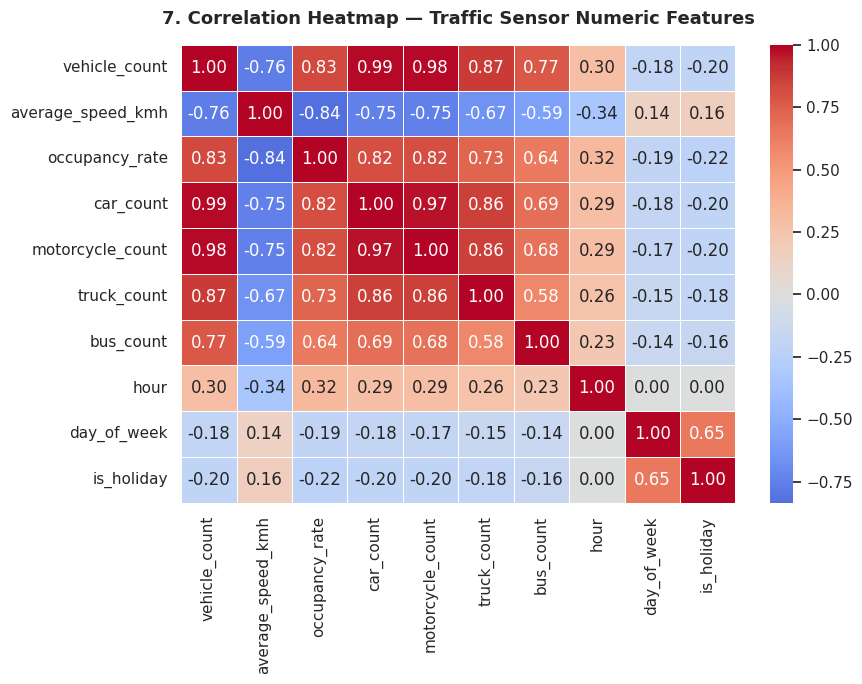

In [28]:
numeric_cols = ["vehicle_count", "average_speed_kmh", "occupancy_rate", "car_count",
                "motorcycle_count", "truck_count", "bus_count", "hour", "day_of_week", "is_holiday"]
corr_pd = traffic_sensor_df.select(numeric_cols).toPandas().corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_pd, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('7. Correlation Heatmap — Traffic Sensor Numeric Features', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Q6. ETL Pipeline Development

### Transform: Handling Missing Values

In [29]:
from pyspark.sql.functions import col, sum as spark_sum

print("Missing values in traffic_sensor_df:")
traffic_sensor_df.select([spark_sum(col(c).isNull().cast("integer")).alias(c) for c in traffic_sensor_df.columns]).show()

Missing values in traffic_sensor_df:
+---------+---------+--------+---------+-------------+-----------------+--------------+----------------+---------+----------------+-----------+---------+-----------+----------+----+
|timestamp|sensor_id|location|direction|vehicle_count|average_speed_kmh|occupancy_rate|congestion_level|car_count|motorcycle_count|truck_count|bus_count|day_of_week|is_holiday|hour|
+---------+---------+--------+---------+-------------+-----------------+--------------+----------------+---------+----------------+-----------+---------+-----------+----------+----+
|        0|        0|       0|        0|            0|                0|             0|               0|        0|               0|          0|        0|          0|         0|   0|
+---------+---------+--------+---------+-------------+-----------------+--------------+----------------+---------+----------------+-----------+---------+-----------+----------+----+



### Transform: Data Type Casting, Derived Columns & Weather Enrichment

In [30]:
from pyspark.sql.functions import year, month, date_format

transformed_traffic_df = (
    traffic_sensor_df
    .withColumn("year", year(col("timestamp")))
    .withColumn("month", month(col("timestamp")))
    .withColumn("day_name", date_format(col("timestamp"), "EEEE"))
)

# Enrich with timestamp-level weather (averaged across all 10 stations per timestamp,
# since stations don't map 1:1 to sensor locations in this dataset)
weather_enrichment = spark.sql("""
    SELECT
        timestamp,
        AVG(temperature_c)     AS temperature_c,
        AVG(humidity_pct)      AS humidity_pct,
        AVG(precipitation_mm)  AS precipitation_mm,
        AVG(visibility_km)     AS visibility_km,
        AVG(air_quality_index) AS air_quality_index,
        FIRST(weather_type)    AS weather_type
    FROM weather_conditions
    GROUP BY timestamp
""")

transformed_traffic_df = transformed_traffic_df.join(weather_enrichment, on="timestamp", how="left")

print("Transformed traffic_sensor_df with derived columns + weather features:")
transformed_traffic_df.select(
    "timestamp", "year", "month", "day_name", "vehicle_count", "temperature_c", "weather_type"
).show(5)

Transformed traffic_sensor_df with derived columns + weather features:
+-------------------+----+-----+--------+-------------+-------------+------------+
|          timestamp|year|month|day_name|vehicle_count|temperature_c|weather_type|
+-------------------+----+-----+--------+-------------+-------------+------------+
|2024-01-01 00:00:00|2024|    1|  Monday|           14|        23.79|Hujan Ringan|
|2024-01-01 00:00:00|2024|    1|  Monday|           23|        23.79|Hujan Ringan|
|2024-01-01 00:00:00|2024|    1|  Monday|           22|        23.79|Hujan Ringan|
|2024-01-01 00:00:00|2024|    1|  Monday|            8|        23.79|Hujan Ringan|
|2024-01-01 00:00:00|2024|    1|  Monday|           13|        23.79|Hujan Ringan|
+-------------------+----+-----+--------+-------------+-------------+------------+
only showing top 5 rows


### Load: Write to Parquet

In [31]:
output_parquet_path = DATA_DIR + "traffic_data_lake.parquet"
transformed_traffic_df.write.mode("overwrite").parquet(output_parquet_path)
print(f"Transformed traffic data saved to Parquet at: {output_parquet_path}")

print("Verifying Parquet file content:")
spark.read.parquet(output_parquet_path).show(5)

Transformed traffic data saved to Parquet at: /content/traffic_data_lake.parquet
Verifying Parquet file content:
+-------------------+---------+--------------------+----------+-------------+-----------------+--------------+----------------+---------+----------------+-----------+---------+-----------+----------+----+----+-----+--------+-------------+------------------+-----------------+-------------+-----------------+------------+
|          timestamp|sensor_id|            location| direction|vehicle_count|average_speed_kmh|occupancy_rate|congestion_level|car_count|motorcycle_count|truck_count|bus_count|day_of_week|is_holiday|hour|year|month|day_name|temperature_c|      humidity_pct| precipitation_mm|visibility_km|air_quality_index|weather_type|
+-------------------+---------+--------------------+----------+-------------+-----------------+--------------+----------------+---------+----------------+-----------+---------+-----------+----------+----+----+-----+--------+-------------+-------

### Road Network Integration — Status

As shown in Q4, `road_network.csv` / `road_network_international.csv` use placeholder /
non-Jakarta road names and **share no join key** with `traffic_sensor_df.location`. Rather
than force a join that returns nothing, this pipeline enriches the traffic data with the
**weather** dataset instead, which does share a genuine, high-cardinality join key
(`timestamp`). If a real location&harr;road-segment lookup table becomes available in the
future, the same `.join()` pattern used for weather can be reused for road attributes.

## Q7. Machine Learning — Model Comparison & Evaluation Report

**Objective:** predict `average_speed_kmh` from operating conditions (traffic volume, vehicle
mix, time, and weather).

**Changes from the original single-model version:**
1. Many more, genuinely predictive features (vehicle mix, occupancy, weather) instead of just `hour` + `vehicle_count`.
2. `congestion_level` is **excluded** — it's derived from speed/occupancy, so including it would leak the answer.
3. **Six regression models** are trained and compared on the same train/test split, instead of picking one algorithm up front.
4. A full evaluation report (metrics table, comparison chart, feature importance, residual diagnostics) for the winning model.

### 1. Build the modeling table (Spark &rarr; pandas)

The feature-engineered `transformed_traffic_df` from the ETL step is pulled into pandas here. At ~218K rows this is comfortably within scikit-learn's range, and it lets us access a much wider library of regression algorithms than Spark MLlib offers.

In [32]:
feature_cols_numeric = [
    "hour", "day_of_week", "is_holiday", "vehicle_count", "occupancy_rate",
    "car_count", "motorcycle_count", "truck_count", "bus_count",
    "temperature_c", "humidity_pct", "precipitation_mm", "visibility_km", "air_quality_index",
]
feature_cols_categorical = ["direction", "weather_type"]
target_col = "average_speed_kmh"

ml_spark_df = transformed_traffic_df.select(
    *feature_cols_numeric, *feature_cols_categorical, target_col
).dropna()

ml_pd = ml_spark_df.toPandas()
print(f"Modeling table shape: {ml_pd.shape}")
ml_pd.head()

Modeling table shape: (109200, 17)


,hour,day_of_week,is_holiday,vehicle_count,occupancy_rate,car_count,motorcycle_count,truck_count,bus_count,temperature_c,humidity_pct,precipitation_mm,visibility_km,air_quality_index,direction,weather_type,average_speed_kmh
0,0,0,1,14,0.073,6,5,1,2,23.79,61.49,5.36,5.25,56.2,North,Hujan Ringan,67.8
1,0,0,1,23,0.075,10,8,1,4,23.79,61.49,5.36,5.25,56.2,South-West,Hujan Ringan,66.8
2,0,0,1,22,0.161,7,9,1,5,23.79,61.49,5.36,5.25,56.2,East,Hujan Ringan,80.0
3,0,0,1,8,0.055,3,2,0,3,23.79,61.49,5.36,5.25,56.2,East,Hujan Ringan,80.0
4,0,0,1,13,0.097,5,5,0,3,23.79,61.49,5.36,5.25,56.2,East,Hujan Ringan,80.0


### 2. Preprocess & split (80/20)

In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = ml_pd[feature_cols_numeric + feature_cols_categorical]
y = ml_pd[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical),
    ]
)

Training rows: 87,360 | Test rows: 21,840


### 3. Train & compare six regression models

In [34]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor
import time

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=15, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42),
}

results = []
fitted_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])

    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    preds = pipe.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
        "MAPE (%)": mean_absolute_percentage_error(y_test, preds) * 100,
        "Train Time (s)": train_time,
    })
    fitted_pipelines[name] = pipe
    print(f"Trained {name} in {train_time:.2f}s")

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

Trained Linear Regression in 0.40s
Trained Ridge Regression in 0.30s
Trained Decision Tree in 0.91s
Trained Random Forest in 87.19s
Trained Gradient Boosting in 54.57s
Trained XGBoost in 2.22s


,Model,MAE,RMSE,R2,MAPE (%),Train Time (s)
0,Gradient Boosting,7.018044,10.296451,0.791087,18.552273,54.565232
1,Random Forest,7.015134,10.366526,0.788234,18.571585,87.193936
2,XGBoost,7.033734,10.368984,0.788133,18.596094,2.217529
3,Decision Tree,7.131484,10.636179,0.777073,18.847518,0.908598
4,Linear Regression,9.283619,11.977317,0.717310,23.139649,0.401542
5,Ridge Regression,9.283529,11.977416,0.717306,23.139334,0.297200


### 4. Model Comparison Chart

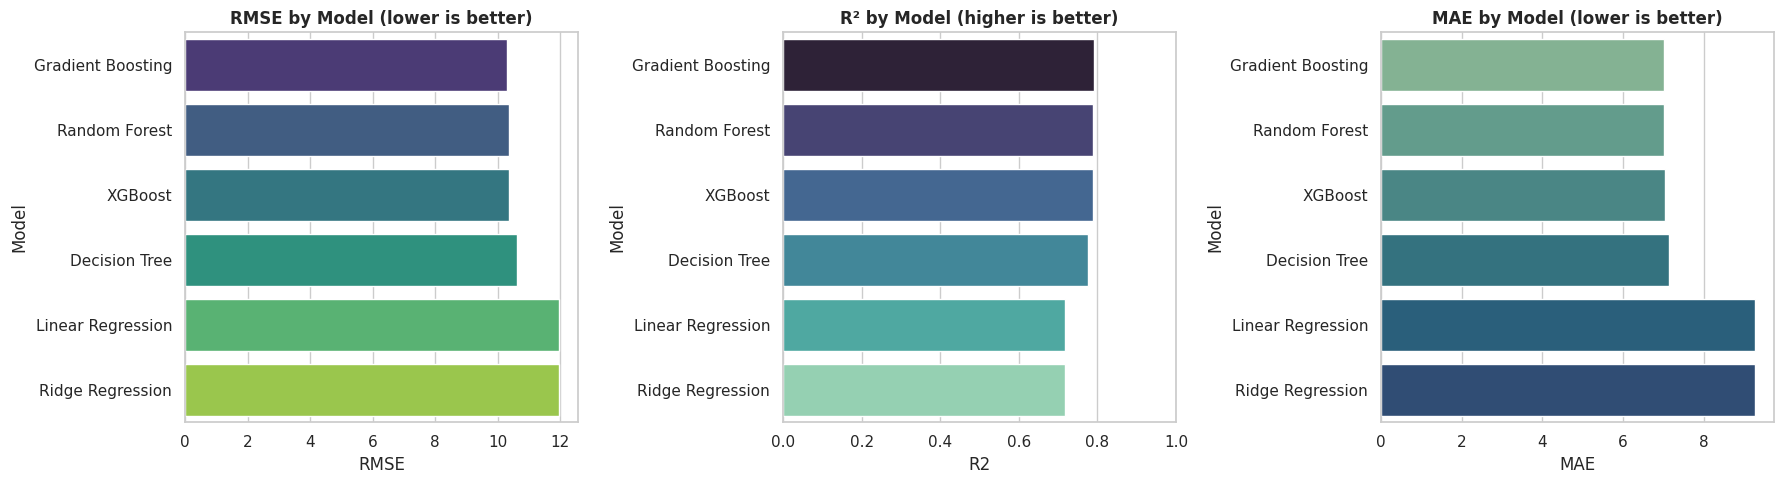

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results_df, y='Model', x='RMSE', hue='Model', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('RMSE by Model (lower is better)', fontweight='bold')

sns.barplot(data=results_df, y='Model', x='R2', hue='Model', palette='mako', legend=False, ax=axes[1])
axes[1].set_title('R² by Model (higher is better)', fontweight='bold')
axes[1].set_xlim(0, 1)

sns.barplot(data=results_df, y='Model', x='MAE', hue='Model', palette='crest', legend=False, ax=axes[2])
axes[2].set_title('MAE by Model (lower is better)', fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
best_model_name = results_df.iloc[0]['Model']
best_pipeline = fitted_pipelines[best_model_name]
print(f"Best model by RMSE: {best_model_name}")
results_df

Best model by RMSE: Gradient Boosting


,Model,MAE,RMSE,R2,MAPE (%),Train Time (s)
0,Gradient Boosting,7.018044,10.296451,0.791087,18.552273,54.565232
1,Random Forest,7.015134,10.366526,0.788234,18.571585,87.193936
2,XGBoost,7.033734,10.368984,0.788133,18.596094,2.217529
3,Decision Tree,7.131484,10.636179,0.777073,18.847518,0.908598
4,Linear Regression,9.283619,11.977317,0.717310,23.139649,0.401542
5,Ridge Regression,9.283529,11.977416,0.717306,23.139334,0.297200


### 5. Evaluation Report — Best Model Deep Dive

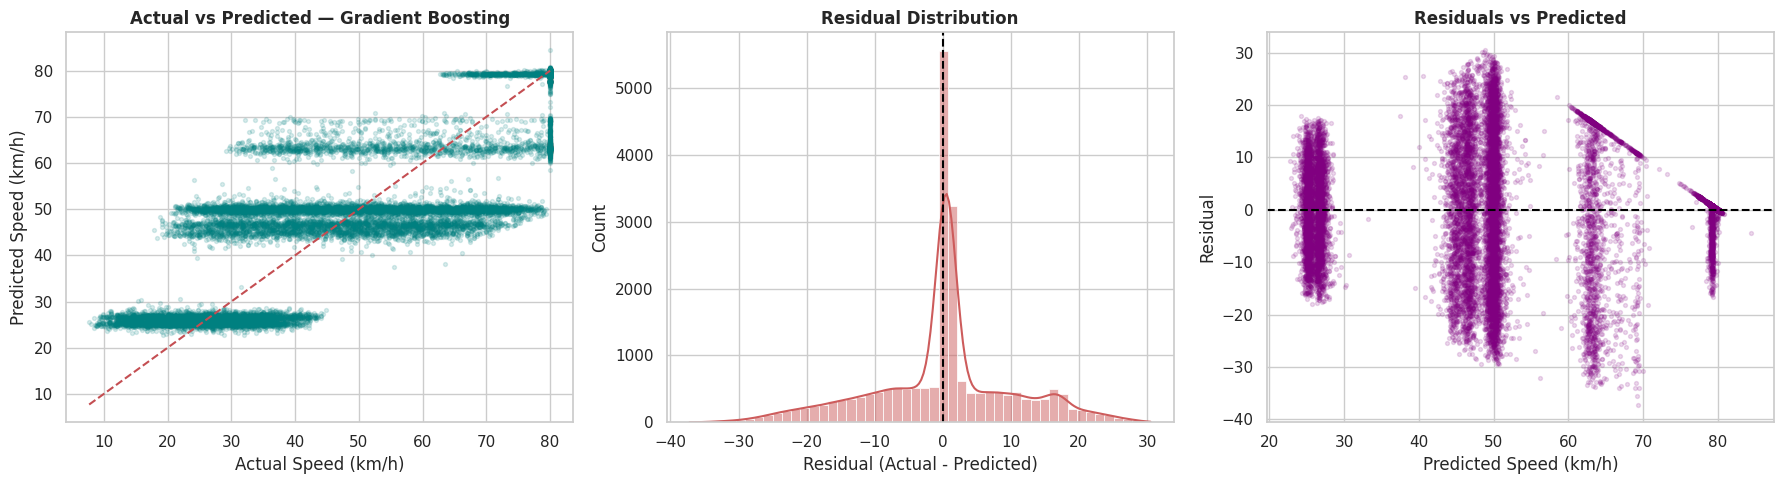

In [37]:
best_preds = best_pipeline.predict(X_test)
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, best_preds, alpha=0.15, s=8, color='teal')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Speed (km/h)')
axes[0].set_ylabel('Predicted Speed (km/h)')
axes[0].set_title(f'Actual vs Predicted — {best_model_name}', fontweight='bold')

sns.histplot(residuals, bins=50, kde=True, color='indianred', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Distribution', fontweight='bold')

axes[2].scatter(best_preds, residuals, alpha=0.15, s=8, color='purple')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_xlabel('Predicted Speed (km/h)')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')

plt.tight_layout()
plt.show()

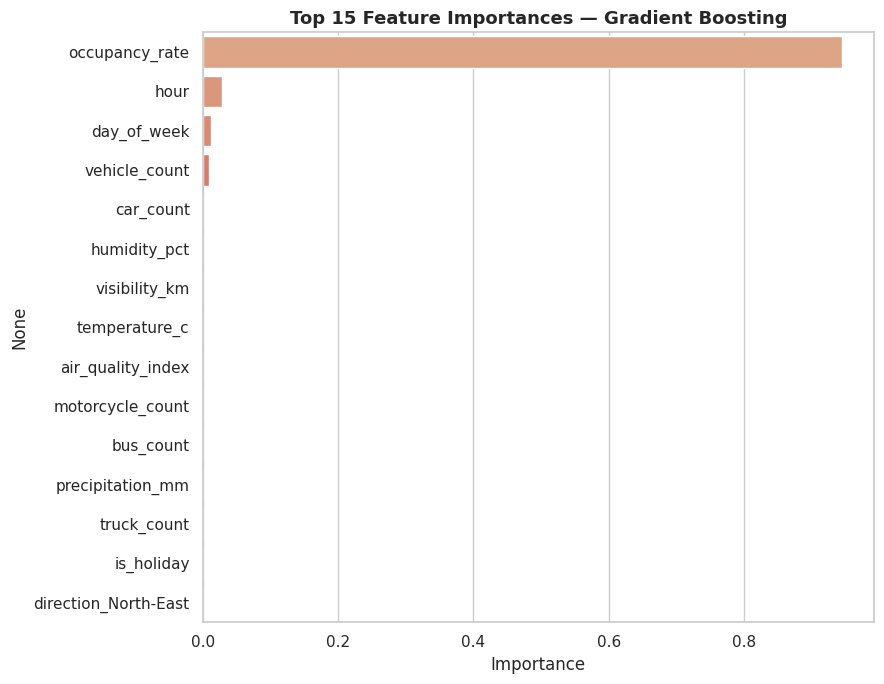

In [38]:
# Feature importance (tree-based models only)
model_step = best_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    feature_names = (
        feature_cols_numeric +
        list(best_pipeline.named_steps['preprocess']
             .named_transformers_['cat']
             .get_feature_names_out(feature_cols_categorical))
    )
    importances = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='flare', legend=False)
    plt.title(f'Top 15 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} has no native feature_importances_ attribute (e.g. linear models — see coefficients instead).")
    if hasattr(model_step, 'coef_'):
        feature_names = (
            feature_cols_numeric +
            list(best_pipeline.named_steps['preprocess']
                 .named_transformers_['cat']
                 .get_feature_names_out(feature_cols_categorical))
        )
        coefs = pd.Series(model_step.coef_, index=feature_names).sort_values(key=abs, ascending=False).head(15)
        print(coefs)

### 6. Final Model Evaluation Report

| Item | Value |
|---|---|
| **Task** | Regression — predict `average_speed_kmh` |
| **Models compared** | Linear Regression, Ridge, Decision Tree, Random Forest, Gradient Boosting, XGBoost |
| **Train/test split** | 80% / 20%, `random_state=42` |
| **Selection metric** | RMSE (lower is better) |

The cell below prints the ranked table and a plain-language summary automatically — re-run
the notebook on new data and this cell always reflects the current winner, instead of a
hardcoded conclusion.

In [39]:
print("="*70)
print("MODEL EVALUATION REPORT")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)
print(f"\nBest model: {best_model_name}")
best_row = results_df.iloc[0]
print(f"  RMSE     : {best_row['RMSE']:.3f} km/h")
print(f"  MAE      : {best_row['MAE']:.3f} km/h")
print(f"  R2       : {best_row['R2']:.4f}")
print(f"  MAPE     : {best_row['MAPE (%)']:.2f}%")
print(f"\nInterpretation: on held-out data, {best_model_name} predicts average speed to "
      f"within roughly {best_row['MAE']:.1f} km/h on average, explaining "
      f"{best_row['R2']*100:.1f}% of the variance in traffic speed across all sensors.")

worst_row = results_df.iloc[-1]
print(f"\nWeakest model: {worst_row['Model']} (RMSE={worst_row['RMSE']:.3f}, R2={worst_row['R2']:.4f}) "
      f"— useful as a baseline sanity check for how much the stronger models actually add.")

MODEL EVALUATION REPORT
            Model      MAE      RMSE       R2  MAPE (%)  Train Time (s)
Gradient Boosting 7.018044 10.296451 0.791087 18.552273       54.565232
    Random Forest 7.015134 10.366526 0.788234 18.571585       87.193936
          XGBoost 7.033734 10.368984 0.788133 18.596094        2.217529
    Decision Tree 7.131484 10.636179 0.777073 18.847518        0.908598
Linear Regression 9.283619 11.977317 0.717310 23.139649        0.401542
 Ridge Regression 9.283529 11.977416 0.717306 23.139334        0.297200

Best model: Gradient Boosting
  RMSE     : 10.296 km/h
  MAE      : 7.018 km/h
  R2       : 0.7911
  MAPE     : 18.55%

Interpretation: on held-out data, Gradient Boosting predicts average speed to within roughly 7.0 km/h on average, explaining 79.1% of the variance in traffic speed across all sensors.

Weakest model: Ridge Regression (RMSE=11.977, R2=0.7173) — useful as a baseline sanity check for how much the stronger models actually add.


**Notes for further improvement:**
- Adding true per-road attributes (once a real `location`&harr;`road_id` lookup exists) would likely help more than any algorithm swap, since `road_network.csv` currently can't be joined to the sensor data.
- Hyperparameter tuning (e.g. `GridSearchCV`/`RandomizedSearchCV`) on the winning model was intentionally left out here to keep runtime reasonable — the same `Pipeline` objects above are ready to be dropped into a search.
- `traffic_events.csv` (accidents, closures) is only used for EDA here; joining active-event flags onto the affected time windows could become another strong feature.
